# Importing Dependencies -


In [530]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score
import pickle

# IMPORTING THE DATASET --

In [531]:
df=pd.read_csv("Titanic-Dataset.csv")

# FEATURE ENGINEERING :
Making Feature of total family members and family type :

In [532]:
df['fam_memb']=df['Parch']+df['SibSp']+1

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col',
                                  'Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')

df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Acer\AppData\Local\Temp\ipykernel_3840\1781670429.py:3: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [533]:
def family_type(size):
    if size==1:
        return 'Alone'
    if size>4:
        return 'Large'
    else:
        return 'Small'
    
df['fam_type']=df['fam_memb'].apply(family_type)

# Viewing Dataset :

In [534]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,fam_memb,Title,fam_type
217,218,0,2,"Jacobsohn, Mr. Sidney Samuel",male,42.0,1,0,243847,27.0000,NaN,S,2,Mr,Small
161,162,1,2,"Watt, Mrs. James (Elizabeth ""Bessie"" Inglis Mi...",female,40.0,0,0,C.A. 33595,15.7500,NaN,S,1,Mrs,Alone
490,491,0,3,"Hagland, Mr. Konrad Mathias Reiersen",male,NaN,1,0,65304,19.9667,NaN,S,2,Mr,Small


# EXPLORING THE DATASET ----

In [535]:
df.shape

(891, 15)

In [536]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  fam_memb     891 non-null    int64  
 13  Title        891 non-null    object 
 14  fam_type     891 non-null    object 
dtypes: float64(2), int64(6), object(7)
memory usage: 104.5+ KB


In [537]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,fam_memb
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [538]:
df.isna().sum() , df.duplicated().sum()

(PassengerId      0
 Survived         0
 Pclass           0
 Name             0
 Sex              0
 Age            177
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Cabin          687
 Embarked         2
 fam_memb         0
 Title            0
 fam_type         0
 dtype: int64,
 np.int64(0))

In [539]:
df[['Survived','Pclass','Age','Fare','SibSp','Parch']].corr()

,Survived,Pclass,Age,Fare,SibSp,Parch
Survived,1.000000,-0.338481,-0.077221,0.257307,-0.035322,0.081629
Pclass,-0.338481,1.000000,-0.369226,-0.549500,0.083081,0.018443
Age,-0.077221,-0.369226,1.000000,0.096067,-0.308247,-0.189119
Fare,0.257307,-0.549500,0.096067,1.000000,0.159651,0.216225
SibSp,-0.035322,0.083081,-0.308247,0.159651,1.000000,0.414838
Parch,0.081629,0.018443,-0.189119,0.216225,0.414838,1.000000


## EDA

PERCENTAGE OF SURVIVED PEOPLE IN A CLASS VS TOTAL PEOPLE IN THAT CLASS :

([<matplotlib.patches.Wedge at 0x191972e7b10>,
 [Text(-1.0945116165034399, 0.10974662336048131, '1'),
  Text(0.8648529732455734, -0.6797273973206405, '2'),
  Text(0.5900500638173327, 0.9283538776722817, '3')],
 [Text(-0.5970063362746034, 0.05986179456026253, '46.8%'),
  Text(0.47173798540667633, -0.3707603985385311, '35.2%'),
  Text(0.32184548935490875, 0.506374842366699, '18.0%')])

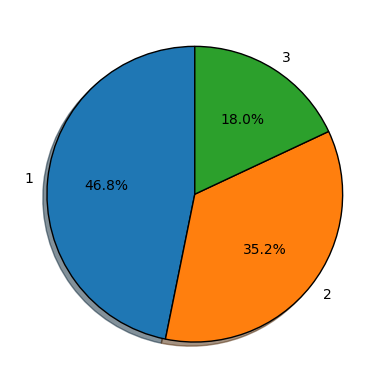

In [540]:
survive_pclass= df.groupby('Pclass')['Survived'].sum()
x_pclass=survive_pclass.index
y_pclass=survive_pclass.values/df.groupby('Pclass')['PassengerId'].count()

plt.pie(y_pclass,labels=x_pclass,shadow=True,startangle=90,autopct='%1.1f%%',
        wedgeprops={'edgecolor':'black'})

# THE SURVIVAL RATE DECREASES AS PCLASS INCREASES.

PERCENTAGE OF SEX OF SURVIVED PEOPLE VS SEX OF TOTAL PEOPLE :

([<matplotlib.patches.Wedge at 0x1919732bd90>,
 [Text(-0.6547015129795749, -0.8839490533408901, 'female'),
  Text(0.6547012249523791, 0.8839492666696739, 'male')],
 [Text(-0.3571099161706772, -0.4821540290950309, '79.7%'),
  Text(0.3571097590649341, 0.4821541454561857, '20.3%')])

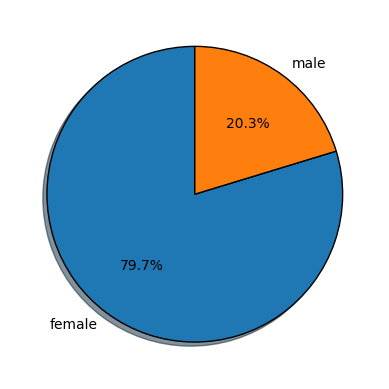

In [541]:
survive_sex= df.groupby('Sex')['Survived'].sum()
x_sex=survive_sex.index
y_sex=survive_sex.values/df.groupby('Sex')['PassengerId'].count()

plt.pie(y_sex,labels=x_sex,shadow=True,startangle=90,autopct='%1.1f%%',
        wedgeprops={'edgecolor':'black'})

# THE SURVIVAL RATE OF FEMALES IS VERY HIGH COMPARED TO MALES.

PERCENTAGE OF EMBARKMENT OF SURVIVED PEOPLE VS TOTAL PEOPLE EMBARKED FROM THAT PLACE :

([<matplotlib.patches.Wedge at 0x19197377b10>,
 [Text(-1.0753097311722954, 0.23175198390988108, 'C'),
  Text(0.5576008961031664, -0.9481989457202249, 'Q'),
  Text(0.8094382173233788, 0.7448555378973502, 'S')],
 [Text(-0.5865325806394338, 0.1264101730417533, '43.2%'),
  Text(0.3041459433289998, -0.5171994249383044, '30.4%'),
  Text(0.4415117549036611, 0.4062848388531, '26.3%')])

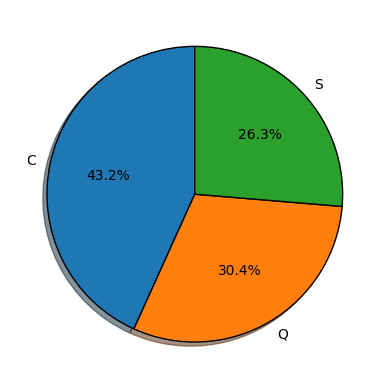

In [542]:
survive_Embarked= df.groupby('Embarked')['Survived'].sum()
x_Embarked=survive_Embarked.index
y_Embarked=survive_Embarked.values/df.groupby('Embarked')['PassengerId'].count()

plt.pie(y_Embarked,labels=x_Embarked,shadow=True,startangle=90,autopct='%1.1f%%',
        wedgeprops={'edgecolor':'black'})

# THE SURVIVAL RATE OF CHERBOURG IS QUITE HIGH COMPARED TO OTHERS TWO.

AGE VS SURVIVED PLOT

<Axes: xlabel='Age', ylabel='Survived'>

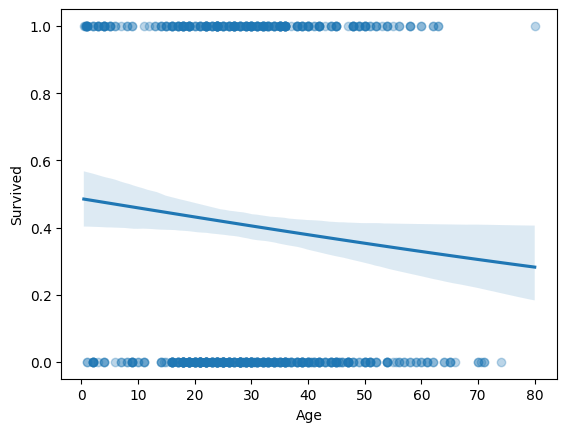

In [543]:
sns.regplot(x=df['Age'],y=df['Survived'],data=df,logistic=True,scatter_kws={'alpha':0.3})

# IN LOWER RANGE OF AGE THE SURVIVAL RATE IS VERY HIGH.

FARE VS SURVIVED PLOT 

<Axes: xlabel='Fare', ylabel='Survived'>

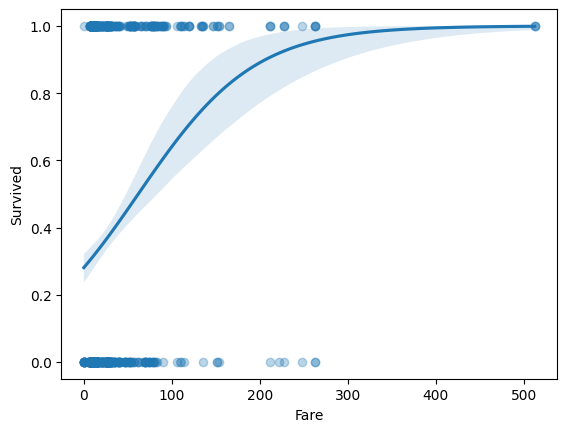

In [544]:
sns.regplot(x=df['Fare'],y=df['Survived'],data=df,logistic=True,scatter_kws={'alpha':0.3})

# THE SURVIVAL RATE INCREAES AS FARE INCREASES.

 FAMILY TYPE VS SURVIVED PLOT 

([<matplotlib.patches.Wedge at 0x19197281590>,
 [Text(-0.8709847329078012, 0.6718523610448403, 'Alone'),
  Text(-0.8106373667703469, -0.7435503073737769, 'Large'),
  Text(1.0838633148930576, -0.1877240384954277, 'Small')],
 [Text(-0.4750825815860733, 0.36646492420627647, '29.1%'),
  Text(-0.4421658364201892, -0.405572894931151, '15.5%'),
  Text(0.5911981717598496, -0.1023949300884151, '55.5%')])

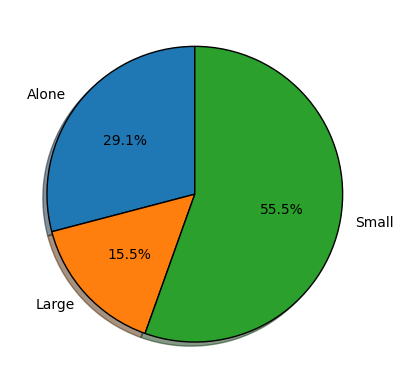

In [545]:
survive_fam= df.groupby('fam_type')['Survived'].sum()
x_fam=survive_fam.index
y_fam=survive_fam.values/df.groupby('fam_type')['PassengerId'].count()

plt.pie(y_fam,labels=x_fam,shadow=True,startangle=90,autopct='%1.1f%%',
        wedgeprops={'edgecolor':'black'})

# THE SURVIVAL RATE OF LARGE FAMILIES IS VERY LOW MAYBE BECAUSE OF DIIFICULTY IN EVACUATION.

<Axes: xlabel='Sex', ylabel='Pclass'>

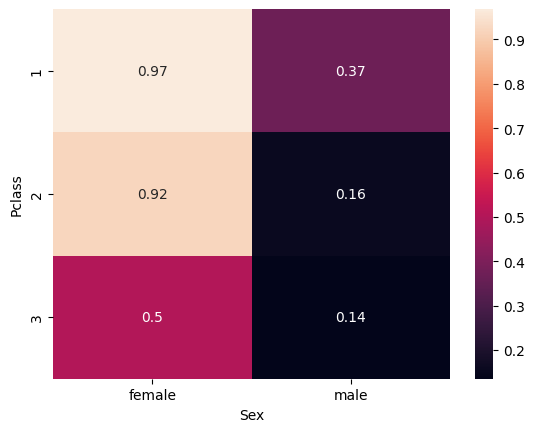

In [546]:
sns.heatmap(pd.crosstab(df['Pclass'], df['Sex'], values=df['Survived'], aggfunc='mean'), annot=True)

# The survival rate of females of pclass 1 is highest while males of pclass3 has lowest.

# VARIABLES OF FEATURES AND TARGET 

In [547]:
x=df[['Sex','Age','Fare','Embarked','fam_type','Pclass','Title']]
y=df['Survived']

# TRAIN TEST SPLIT :

In [548]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [549]:
x_train.shape,x_test.shape

((712, 7), (179, 7))

In [550]:
x_train

,Sex,Age,Fare,Embarked,fam_type,Pclass,Title
331,male,45.5,28.5000,S,Alone,1,Mr
733,male,23.0,13.0000,S,Alone,2,Mr
382,male,32.0,7.9250,S,Alone,3,Mr
704,male,26.0,7.8542,S,Small,3,Mr
813,female,6.0,31.2750,S,Large,3,Miss
...,...,...,...,...,...,...,...
106,female,21.0,7.6500,S,Alone,3,Miss
270,male,NaN,31.0000,S,Alone,1,Mr
860,male,41.0,14.1083,S,Small,3,Mr
435,female,14.0,120.0000,S,Small,1,Miss


# LABELLING THE NUMERICAL AND CATEGORICAL FEATURES

In [551]:
num_features=['Age','Fare']
cat_features=['Sex','Embarked','fam_type','Title']

# FORMING THE NUMBER AND CATEGORY PIPELINES

In [552]:
num_pipe=Pipeline([
    ('Imputor_num',SimpleImputer(strategy='median')),
    ('scaler',MinMaxScaler())
])

cat_pipe=Pipeline([
    ('Imputor_cat',SimpleImputer(strategy='most_frequent')),
    ('OH_Encode',OneHotEncoder(sparse_output=False,drop='first'))
])

# ONE SINGLE TRANSFORMER 

In [553]:
transformer=ColumnTransformer(transformers=[
    ('num',num_pipe,num_features),
    ('cat',cat_pipe,cat_features)
],remainder='passthrough')

# MODELS FOR COMPARING 

In [554]:
model=LogisticRegression(max_iter=2000)
model2=RandomForestClassifier(n_estimators=100,random_state=42)
model3=DecisionTreeClassifier(max_depth=5,random_state=42)

# MAIN PIPELINES OF THREE MODELS--

In [555]:
Main_pipe=Pipeline([
    ('Col_transformer',transformer),
    ('model',model)
])
Main_pipe2=Pipeline([
    ('Col_transformer',transformer),
    ('model',model2)
])
Main_pipe3=Pipeline([
    ('Col_transformer',transformer),
    ('model',model3)
])

# FITTING THE TRAINING DATA AND PREDICTING VALUES

In [556]:
Main_pipe.fit(x_train,y_train)
Main_pipe2.fit(x_train,y_train)
Main_pipe3.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Col_transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [557]:
y_pred=Main_pipe.predict(x_test)
y_pred2=Main_pipe2.predict(x_test)
y_pred3=Main_pipe3.predict(x_test)

# EVALUATION OF MODEL

MODEL 1(LOGISTIC REGRESSION )

In [558]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [559]:
print(confusion_matrix(y_test,y_pred))

[[91 14]
 [17 57]]


In [560]:
cv_score=(cross_val_score(Main_pipe,x_train,y_train,cv=5,scoring='accuracy').mean())*100
print(round(cv_score,2),'%')


82.58 %


MODEL 2 ( RANDOM FOREST)

In [561]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       105
           1       0.79      0.81      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [562]:
print(confusion_matrix(y_test,y_pred2))

[[89 16]
 [14 60]]


In [563]:
cv_score2=(cross_val_score(Main_pipe2,x_train,y_train,cv=5,scoring='accuracy').mean())*100
print(round(cv_score2,2),'%')

79.92 %


MODEL 3 ( DECISION TREE)

In [564]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.83      0.74      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [565]:
print(confusion_matrix(y_test,y_pred3))

[[94 11]
 [19 55]]


In [566]:
cv_score3=(cross_val_score(Main_pipe3,x_train,y_train,cv=5,scoring='accuracy').mean())*100
print(round(cv_score3,2),'%')

80.19 %


# IMPORTANT FEATURES 

In [567]:
model = Main_pipe2.named_steps['model']
features = Main_pipe2.named_steps['Col_transformer'].get_feature_names_out()

import pandas as pd
imp = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
imp = imp.sort_values(by='Importance', ascending=False)

print(imp)

                Feature  Importance
1             num__Fare    0.265330
0              num__Age    0.232655
2         cat__Sex_male    0.131358
8         cat__Title_Mr    0.115494
11    remainder__Pclass    0.080159
9        cat__Title_Mrs    0.040690
7       cat__Title_Miss    0.032730
5   cat__fam_type_Large    0.032636
6   cat__fam_type_Small    0.027850
4       cat__Embarked_S    0.022836
3       cat__Embarked_Q    0.009801
10      cat__Title_Rare    0.008462


Model Comparison:
- Logistic Regression → Accuracy: 82.58 %
- Decision Tree → Accuracy: 79.92 %
- Random Forest → Accuracy: 80.19 %

Although Logistic Regression achieved the highest accuracy, Random Forest was selected due to its ability to capture non-linear relationships and better generalization observed in cross-validation.

# EXPORTING THE PIPE (RANDOM FOREST)

In [568]:
pickle.dump(Main_pipe2,open('pipe.pkl','wb'))